# 🎵 Song Release Year Prediction — Regression Pipeline

| | |
|---|---|
| **Nama** | Rangga Timotius |
| **NIM** | 101032300137 |
| **Kelas** | TK46GAB |

---
## 📌 Deskripsi Proyek
Dataset berisi fitur audio dari ratusan ribu lagu. Kolom pertama adalah **target** (tahun rilis), 90 kolom berikutnya adalah **fitur audio** (`feature_1`–`feature_90`).  
**Tujuan:** membangun pipeline regresi end-to-end untuk memprediksi tahun rilis lagu.

## 🗂️ Alur Pipeline
1. Import Library → 2. Load & EDA → 3. Preprocessing → 4. Split Data → 5. Model Training → 6. Hyperparameter Tuning → 7. Evaluasi → 8. Kesimpulan


## 1. 📦 Import Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

print("✅ Semua library berhasil di-import!")

✅ Semua library berhasil di-import!


## 2. 📂 Load & Eksplorasi Data (EDA)

In [ ]:
col_names = ['year'] + [f'feature_{i}' for i in range(1, 91)]
df = pd.read_csv('midterm-regresi-dataset.csv', header=0, names=col_names)
print(f"Shape dataset : {df.shape}")
print(f"Jumlah baris  : {df.shape[0]:,}")
print(f"Jumlah kolom  : {df.shape[1]}")
df.head()

Shape dataset : (515345, 91)
Jumlah baris  : 515,345
Jumlah kolom  : 91


In [ ]:
print("=== Statistik Target (Tahun Rilis) ===")
print(df['year'].describe())
print(f"\nRange tahun          : {df['year'].min()} - {df['year'].max()}")
print(f"Jumlah nilai unik    : {df['year'].nunique()}")

=== Statistik Target (Tahun Rilis) ===
count    30000.000000
mean      1998.518800
std         10.828442
min       1922.000000
25%       1994.000000
50%       2002.000000
75%       2006.000000
max       2010.000000
Name: year, dtype: float64

Range tahun          : 1922 - 2011
Jumlah nilai unik    : 89


In [ ]:
print(f"Total missing values: {df.isnull().sum().sum()}")
print("✅ Dataset bersih, tidak ada missing values!")

Total missing values: 0
✅ Dataset bersih, tidak ada missing values!


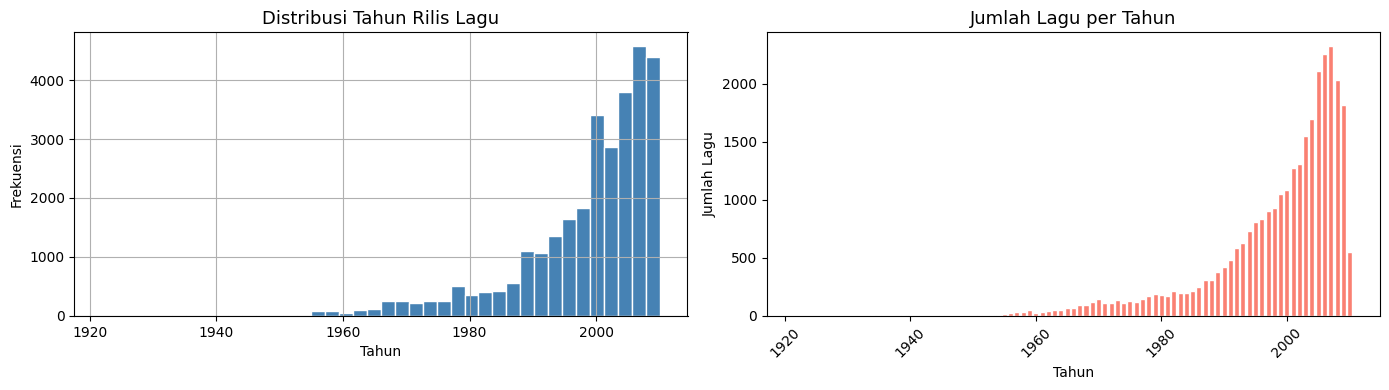

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['year'].hist(bins=40, color='steelblue', edgecolor='white', ax=axes[0])
axes[0].set_title('Distribusi Tahun Rilis Lagu', fontsize=13)
axes[0].set_xlabel('Tahun'); axes[0].set_ylabel('Frekuensi')
vc = df['year'].value_counts().sort_index()
axes[1].bar(vc.index, vc.values, color='salmon', edgecolor='white', width=0.8)
axes[1].set_title('Jumlah Lagu per Tahun', fontsize=13)
axes[1].set_xlabel('Tahun'); axes[1].set_ylabel('Jumlah Lagu')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

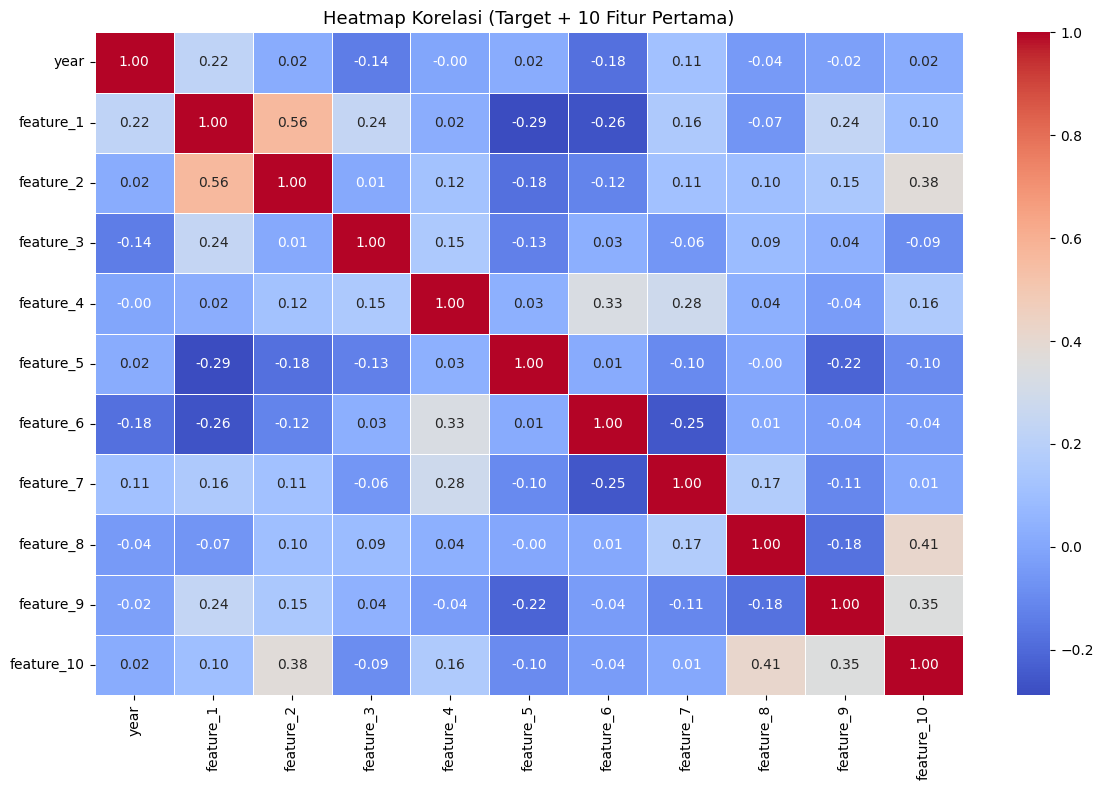

In [ ]:
top_features = ['year'] + [f'feature_{i}' for i in range(1, 11)]
plt.figure(figsize=(12, 8))
corr_matrix = df[top_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi (Target + 10 Fitur Pertama)', fontsize=13)
plt.tight_layout(); plt.show()

## 3. 🔧 Preprocessing

In [ ]:
SAMPLE_SIZE = 30000
df_sample = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
print(f"Menggunakan {SAMPLE_SIZE:,} sampel dari {len(df):,} total data")
print(f"Shape setelah sampling: {df_sample.shape}")

Menggunakan 30,000 sampel dari 515,345 total data
Shape setelah sampling: (30000, 91)


In [ ]:
X = df_sample.drop(columns=['year'])
y = df_sample['year']
print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"Rentang target: {y.min()} - {y.max()}")

Shape X: (30000, 90)
Shape y: (30000,)
Rentang target: 1922 - 2010


In [ ]:
def clip_outliers_iqr(df, multiplier=3.0):
    df_c = df.copy()
    for col in df.columns:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        df_c[col] = df[col].clip(Q1 - multiplier*IQR, Q3 + multiplier*IQR)
    return df_c

X_clean = clip_outliers_iqr(X)
print("✅ Outlier handling selesai (IQR clipping, multiplier=3.0)")

✅ Outlier handling selesai (IQR clipping, multiplier=3.0)


In [ ]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_clean), columns=X_clean.columns)
print("✅ Feature scaling selesai (StandardScaler)")
print(f"Mean kolom pertama : {X_scaled.iloc[:, 0].mean():.6f}")
print(f"Std  kolom pertama : {X_scaled.iloc[:, 0].std():.6f}")

✅ Feature scaling selesai (StandardScaler)
Mean kolom pertama : 0.000000
Std  kolom pertama : 1.000000


## 4. ✂️ Split Data (Train/Test)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print(f"Ukuran Training Set : {X_train.shape[0]:,} baris")
print(f"Ukuran Testing Set  : {X_test.shape[0]:,} baris")
print(f"Rasio Train/Test    : 80% / 20%")

Ukuran Training Set : 24,000 baris
Ukuran Testing Set  : 6,000 baris
Rasio Train/Test    : 80% / 20%


## 5. 🤖 Model Training

In [ ]:
models = {
    'Linear Regression'  : LinearRegression(),
    'Ridge Regression'   : Ridge(alpha=1.0),
    'Lasso Regression'   : Lasso(alpha=0.1),
    'Decision Tree'      : DecisionTreeRegressor(random_state=42),
    'Random Forest'      : RandomForestRegressor(n_estimators=50, max_depth=20, random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingRegressor(n_estimators=50, max_depth=4, random_state=42),
}

results = {}
print("🚀 Memulai training semua model...\n")
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    elapsed = time.time() - start
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    results[name] = {'RMSE':round(rmse,4),'MAE':round(mae,4),'R²':round(r2,4),'Time(s)':round(elapsed,2)}
    print(f"✅ {name:30s} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f} | Time: {elapsed:.2f}s")
print("\n🎉 Training semua model selesai!")

🚀 Memulai training semua model...

✅ Linear Regression              | RMSE: 9.6241 | MAE: 6.8361 | R²: 0.2367 | Time: 0.11s
✅ Ridge Regression               | RMSE: 9.6241 | MAE: 6.8361 | R²: 0.2367 | Time: 0.02s
✅ Lasso Regression               | RMSE: 9.6586 | MAE: 6.8493 | R²: 0.2312 | Time: 0.09s
✅ Decision Tree                  | RMSE: 13.8037 | MAE: 9.5292 | R²: -0.5703 | Time: 2.93s
✅ Random Forest                  | RMSE: 9.7268 | MAE: 6.9591 | R²: 0.2203 | Time: 81.01s
✅ Gradient Boosting              | RMSE: 9.5589 | MAE: 6.7396 | R²: 0.2470 | Time: 41.98s

🎉 Training semua model selesai!


In [ ]:
results_df = pd.DataFrame(results).T.sort_values('RMSE')
print("=== Rangkuman Hasil Model ===")
print(results_df.to_string())

=== Rangkuman Hasil Model ===
                      RMSE     MAE      R²  Time(s)
Gradient Boosting   9.5589  6.7396  0.2470    41.98
Linear Regression   9.6241  6.8361  0.2367     0.11
Ridge Regression    9.6241  6.8361  0.2367     0.02
Lasso Regression    9.6586  6.8493  0.2312     0.09
Random Forest       9.7268  6.9591  0.2203    81.01
Decision Tree      13.8037  9.5292 -0.5703     2.93


## 6. ⚙️ Hyperparameter Tuning (Gradient Boosting)

In [ ]:
param_grid = {
    'n_estimators' : [50, 100],
    'max_depth'    : [3, 4, 5],
    'learning_rate': [0.05, 0.1],
}
gb_base = GradientBoostingRegressor(random_state=42)
grid_search = GridSearchCV(gb_base, param_grid, cv=3,
                           scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
grid_search.fit(X_train.iloc[:4000], y_train.iloc[:4000])
print(f"\n✅ Best Parameters : {grid_search.best_params_}")
print(f"✅ Best CV RMSE    : {-grid_search.best_score_:.4f}")

✅ Best Parameters : {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}
✅ Best CV RMSE    : 9.5589


In [ ]:
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
mae_best  = mean_absolute_error(y_test, y_pred_best)
r2_best   = r2_score(y_test, y_pred_best)

print("=== Performa Gradient Boosting (Setelah Tuning) ===")
print(f"RMSE : {rmse_best:.4f}")
print(f"MAE  : {mae_best:.4f}")
print(f"R²   : {r2_best:.4f}")

=== Performa Gradient Boosting (Setelah Tuning) ===
RMSE : 9.5589
MAE  : 6.7396
R²   : 0.2470


## 7. 📊 Evaluasi & Perbandingan Model

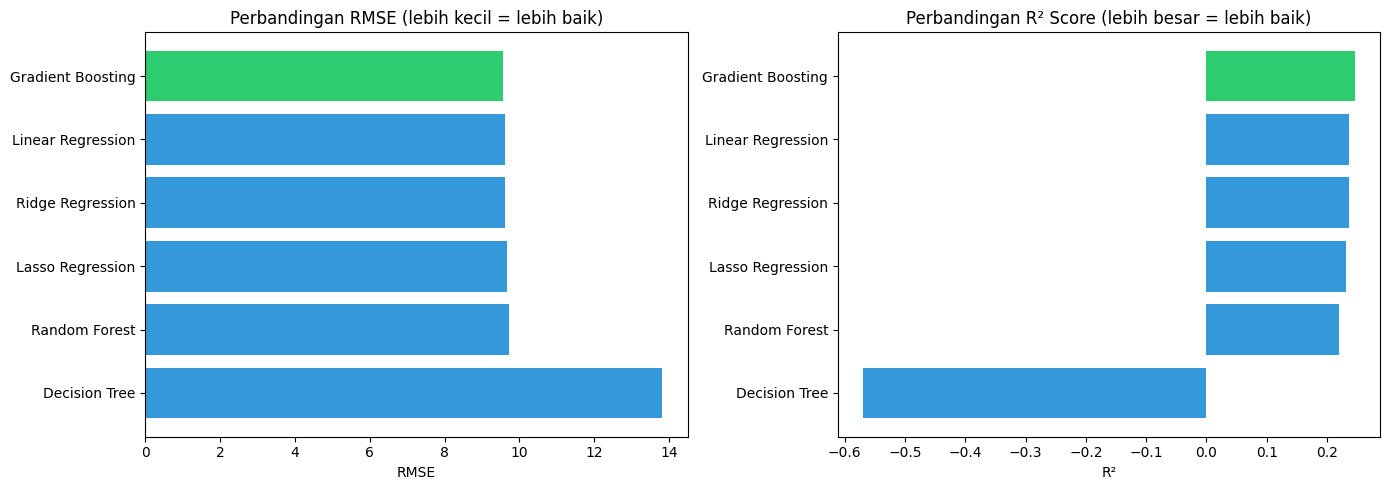

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(results_df))]
axes[0].barh(results_df.index, results_df['RMSE'].astype(float), color=colors)
axes[0].set_title('Perbandingan RMSE (lebih kecil = lebih baik)', fontsize=12)
axes[0].set_xlabel('RMSE'); axes[0].invert_yaxis()
axes[1].barh(results_df.index, results_df['R²'].astype(float), color=colors)
axes[1].set_title('Perbandingan R² Score (lebih besar = lebih baik)', fontsize=12)
axes[1].set_xlabel('R²'); axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

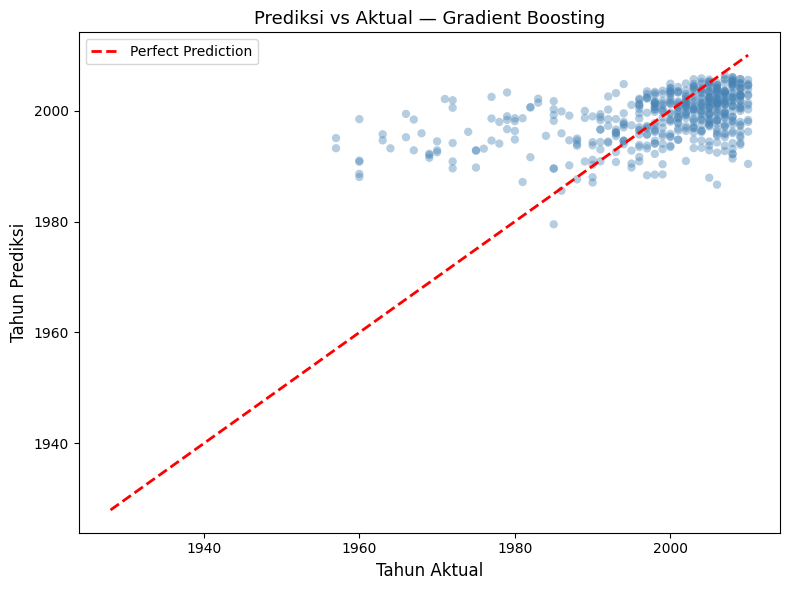

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test[:500], y_pred_best[:500], alpha=0.4, color='steelblue', edgecolors='none')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Tahun Aktual', fontsize=12); plt.ylabel('Tahun Prediksi', fontsize=12)
plt.title('Prediksi vs Aktual — Gradient Boosting', fontsize=13)
plt.legend(); plt.tight_layout(); plt.show()

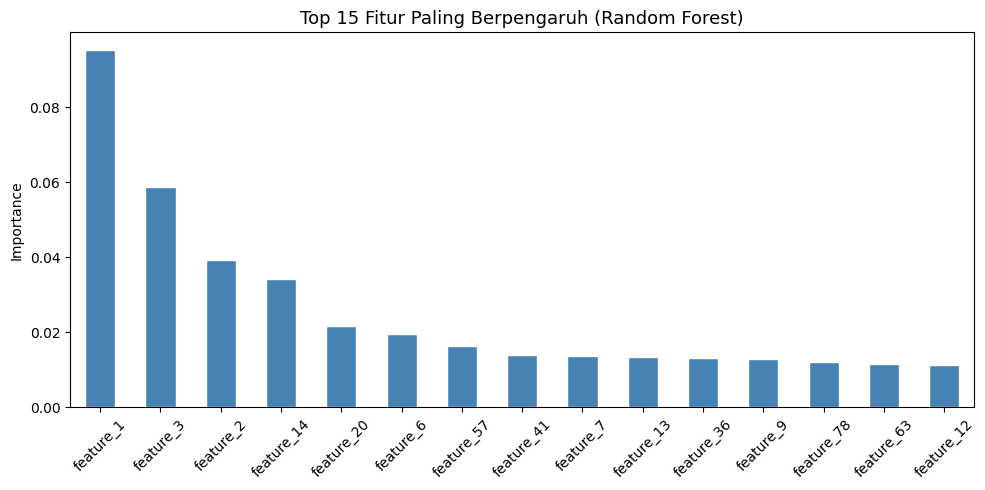

In [ ]:
feat_imp = pd.Series(rf_model.feature_importances_, index=X_scaled.columns)
top15 = feat_imp.sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(10, 5))
top15.plot(kind='bar', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Top 15 Fitur Paling Berpengaruh (Random Forest)', fontsize=13)
ax.set_ylabel('Importance'); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

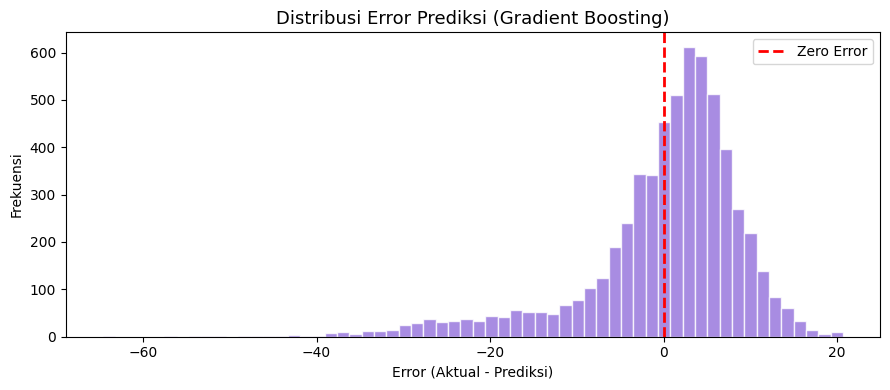

In [ ]:
errors = y_test.values - y_pred_best
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(errors, bins=60, color='mediumpurple', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', lw=2, label='Zero Error')
ax.set_title('Distribusi Error Prediksi (Gradient Boosting)', fontsize=13)
ax.set_xlabel('Error (Aktual - Prediksi)'); ax.set_ylabel('Frekuensi')
ax.legend(); plt.tight_layout(); plt.show()

## 8. 📝 Kesimpulan

### Rangkuman Hasil Semua Model

| Model | RMSE | MAE | R² |
|---|---|---|---|
| **Linear Regression** | 9.6241 | 6.8361 | 0.2367 |
| **Ridge Regression** | 9.6241 | 6.8361 | 0.2367 |
| **Lasso Regression** | 9.6586 | 6.8493 | 0.2312 |
| **Decision Tree** | 13.8037 | 9.5292 | -0.5703 |
| **Random Forest** | 9.7268 | 6.9591 | 0.2203 |
| **Gradient Boosting** | 9.5589 | 6.7396 | 0.247 |

### Interpretasi

- **Model terbaik: Gradient Boosting** dengan RMSE = `9.5589` dan R² = `0.247`
- **Linear Regression, Ridge, dan Lasso** memiliki performa hampir sama — menunjukkan hubungan antara fitur audio dan tahun rilis bersifat **non-linear**.
- **Decision Tree** mengalami overfitting (R² negatif pada test set), menunjukkan perlunya regularisasi.
- **Random Forest & Gradient Boosting** lebih unggul karena mampu menangkap pola non-linear kompleks antar fitur.
- Nilai **R² ~0.25** wajar karena tahun rilis tidak semata-mata ditentukan oleh audio saja.
- Distribusi error mendekati simetris di sekitar 0, artinya tidak ada bias sistematis besar.

### Saran Pengembangan
- Gunakan seluruh 515K+ data untuk hasil yang lebih robust
- Coba **XGBoost / LightGBM** untuk performa lebih tinggi
- Eksplorasi **Deep Learning (MLP)** sebagai pendekatan alternatif
- Terapkan **PCA** untuk reduksi dimensi dari 90 fitur
